## Nuevo modelo combinando los data set ASVspoof2019 y Latinoamerica

### Introducción

El análisis del modelo original de Alexis con CNN entrenada con ASVspoof 2019 y tipos A01-A06, nos mostró  una limitación estructural crítica al evaluarlo sobre el eval set con lso tipos A07 a A19, los cuales el modleo nunca los vio durante el entrenamiento. Aunque el ROC-AUC fue de 0.93, el F1-bonafide fue muy bajo con un 0.59 y la precision de al mimso bonafide de 0.47.

Al hacer el análisis del protocolo oficial de ASVspoof 2019 identificamos la causa raíz:

| Limitación | Detalle |
|------------|---------|
| Solo 20 hablantes bonafide en train | 0 hablantes en común con el eval set |
| 67 hablantes bonafide nuevos en eval | El modelo nunca los había visto |
| Solo 6 sistemas de spoof en train | A01-A06, sin exposición a técnicas nuevas |
| 13 sistemas de spoof nuevos en eval | A07-A19, completamente desconocidos |

Intentamos corregir el problema mediante la aplicación de class_weight y data augmentation, pero la mejora fue mínima, teniendo un F1-bonafide de 0.59 y 0.60. Con lo cual confirmamos que el problema no era el balanceo sino la falta de diversidad de hablantes y sistemas de síntesis en los datos de entrenamiento.

### Hipótesis

Un modelo entrenado con mayor diversidad de hablantes, idiomas y sistemas 
de síntesis generalizará mejor a condiciones del mundo real.

### Estrategia

Para validar esta hipótesis se construyó un train set enriquecido que combina tres fuentes de datos:

| Fuente | Contenido | Rol |
|--------|-----------|-----|
| ASVspoof 2019 train (A01-A06) | 25,380 audios en inglés | Train |
| ASVspoof 2019 eval (A07-A19) | 71,237 audios en inglés | Train |
| Latin America dataset (70%) | ~53,000 audios en español | Train |
| Latin America dataset (30%) | ~23,000 audios en español | Test |

Con ssta combinación pretendemos resolver los problemas de las dos limitantes identificadas:
- Diversidad de bonafide: agregamos 22,816 hablantes latinoamericanos en español
- Diversidad de spoof: exponemos al modelo a 19 sistemas de 
síntesis (A01-A19) más las 5 técnicas latinoamericanas: CycleGAN, StarGAN, 
TTS, TTS-VC, Diffusion.

Como el test set es exclusivamente del set latinoamericano y nunca fue visto durante el entrenamiento, nos aseguramos de tener una evaluación sin data leakage.


In [1]:
import sys
!{sys.executable} -m pip install tensorflow scikit-learn matplotlib numpy -q


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


 Cargar todos los tensores

In [2]:
# Importar librerías
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils import compute_class_weight

# Configuración de TensorFlow para evitar errores de memoria
# Rutas
RUTA_TRAIN_ASV  = '../Metricas/ETL_V2.1_train/'
RUTA_EVAL_ASV   = '../Metricas/ETL_V2.1_eval/'
RUTA_LATIN      = '../Metricas/ETL_LatinAmerica/'

# Cargar ASVspoof train (A01-A06)
X_asv_train = np.load(RUTA_TRAIN_ASV + 'X_fourier_features.npy')
y_asv_train = np.load(RUTA_TRAIN_ASV + 'y_labels.npy')

# Cargar ASVspoof eval (A07-A19)
X_asv_eval  = np.load(RUTA_EVAL_ASV + 'X_fourier_features.npy')
y_asv_eval  = np.load(RUTA_EVAL_ASV + 'y_labels.npy')

# Cargar Latin America
X_latin     = np.load(RUTA_LATIN + 'X_fourier_features.npy')
y_latin     = np.load(RUTA_LATIN + 'y_labels.npy')

print('=== Tensores cargados ===')
print(f'ASVspoof train (A01-A06) : {X_asv_train.shape} | bonafide: {(y_asv_train==0).sum()} spoof: {(y_asv_train==1).sum()}')
print(f'ASVspoof eval  (A07-A19) : {X_asv_eval.shape}  | bonafide: {(y_asv_eval==0).sum()} spoof: {(y_asv_eval==1).sum()}')
print(f'Latin America            : {X_latin.shape}     | bonafide: {(y_latin==0).sum()} spoof: {(y_latin==1).sum()}')


=== Tensores cargados ===
ASVspoof train (A01-A06) : (25380, 5, 1025, 1) | bonafide: 2580 spoof: 22800
ASVspoof eval  (A07-A19) : (71237, 5, 1025, 1)  | bonafide: 7355 spoof: 63882
Latin America            : (75816, 5, 1025, 1)     | bonafide: 22816 spoof: 53000


Split 70/30 del dataset latinoamericano

In [3]:
# Split de ASVspoof train (A01-A06) en train y test
X_lat_train, X_lat_test, y_lat_train, y_lat_test = train_test_split(
    X_latin, y_latin,
    test_size=0.30,
    random_state=42,
    stratify=y_latin
)

print('=== Split Latin America ===')
print(f'Train (70%): {X_lat_train.shape} | bonafide: {(y_lat_train==0).sum()} spoof: {(y_lat_train==1).sum()}')
print(f'Test  (30%): {X_lat_test.shape}  | bonafide: {(y_lat_test==0).sum()}  spoof: {(y_lat_test==1).sum()}')


=== Split Latin America ===
Train (70%): (53071, 5, 1025, 1) | bonafide: 15971 spoof: 37100
Test  (30%): (22745, 5, 1025, 1)  | bonafide: 6845  spoof: 15900


Combinar train enriquecido

In [4]:
# ASVspoof completo (A01-A19) + 70% Latin America
X_train = np.concatenate([X_asv_train, X_asv_eval, X_lat_train])
y_train = np.concatenate([y_asv_train, y_asv_eval, y_lat_train])

# Mezclar aleatoriamente
idx = np.random.permutation(len(X_train))
X_train = X_train[idx]
y_train = y_train[idx]

# Test = 30% Latin America
X_test = X_lat_test
y_test = y_lat_test

print('=== Train enriquecido ===')
print(f'Total train : {X_train.shape}')
print(f'  bonafide  : {(y_train==0).sum()}')
print(f'  spoof     : {(y_train==1).sum()}')
print(f'\nTotal test  : {X_test.shape}')
print(f'  bonafide  : {(y_test==0).sum()}')
print(f'  spoof     : {(y_test==1).sum()}')


=== Train enriquecido ===
Total train : (149688, 5, 1025, 1)
  bonafide  : 25906
  spoof     : 123782

Total test  : (22745, 5, 1025, 1)
  bonafide  : 6845
  spoof     : 15900


Preparar tensores para CNN

In [22]:
# Mantener forma (N, 5, 1025, 1) — NO separar segmentos
# La CNN trata cada audio como imagen: alto=5 segmentos, ancho=1025 frecuencias, canal=1

X_train_cnn = X_train  # shape: (N, 5, 1025, 1)
X_test_cnn  = X_test   # shape: (N, 5, 1025, 1)
y_train_cnn = y_train
y_test_cnn  = y_test

print(f'Shape train CNN : {X_train_cnn.shape}')
print(f'Shape test CNN  : {X_test_cnn.shape}')
print(f'Shape y_train   : {y_train_cnn.shape}')
print(f'Shape y_test    : {y_test_cnn.shape}')

Shape train CNN : (149688, 5, 1025, 1)
Shape test CNN  : (22745, 5, 1025, 1)
Shape y_train   : (149688,)
Shape y_test    : (22745,)


Class weights

In [23]:
# Definir modelo CNN similar al Modelo2_Alexis para que sea comparable, pero con pesos de clase para mejorar la detección de la clase minoritaria (spoof)
from tensorflow.keras import layers, models
from sklearn.utils import compute_class_weight

pesos = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train_cnn  # ← usar y_train_cnn no y_train
)
class_weights = {0: pesos[0], 1: pesos[1]}
print(f'Peso bonafide (real) : {class_weights[0]:.2f}')
print(f'Peso spoof (falso)   : {class_weights[1]:.2f}')


Peso bonafide (real) : 2.89
Peso spoof (falso)   : 0.60


Arquitectura CNN basads en Modelo2_Alexis

In [24]:
# Definir modelo CNN similar al Modelo2_Alexis para que sea comparable, pero con pesos de clase para mejorar la detección de la clase minoritaria (spoof)
from tensorflow.keras import layers, models

input_shape = X_train_cnn.shape[1:]
print(f'Input shape: {input_shape}')

cnn_model = models.Sequential([
    layers.Input(shape=input_shape),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 4)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 4)),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

cnn_model.summary()


Input shape: (5, 1025, 1)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 5, 1025, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 2, 256, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 2, 256, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 1, 64, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 1, 64, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,313 (427.00 KB)

 Trainable params: 109,313 (427.00 KB)

 Non-trainable params: 0 (0.00 B)

Entrenamiento

In [25]:
from tensorflow.keras.callbacks import EarlyStopping

monitor = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print('Iniciando entrenamiento...')
historial = cnn_model.fit(
    X_train_cnn, y_train_cnn,  # ← y_train_cnn
    epochs=50,
    batch_size=32,
    validation_data=(X_test_cnn, y_test_cnn),  # ← y_test_cnn
    callbacks=[monitor],
    class_weight=class_weights,
    verbose=1
)
print('\nEntrenamiento completado.')



Iniciando entrenamiento...
Epoch 1/50
4678/4678 ━━━━━━━━━━━━━━━━━━━━ 39s 8ms/step - accuracy: 0.6044 - auc: 0.7706 - loss: 0.5261 - val_accuracy: 0.4844 - val_auc: 0.6559 - val_loss: 0.7932
Epoch 2/50
4678/4678 ━━━━━━━━━━━━━━━━━━━━ 37s 8ms/step - accuracy: 0.6854 - auc: 0.8382 - loss: 0.4685 - val_accuracy: 0.6935 - val_auc: 0.8490 - val_loss: 0.5344
Epoch 3/50
4678/4678 ━━━━━━━━━━━━━━━━━━━━ 38s 8ms/step - accuracy: 0.7830 - auc: 0.9005 - loss: 0.3863 - val_accuracy: 0.7715 - val_auc: 0.9120 - val_loss: 0.4616
Epoch 4/50
4678/4678 ━━━━━━━━━━━━━━━━━━━━ 38s 8ms/step - accuracy: 0.8159 - auc: 0.9214 - loss: 0.3483 - val_accuracy: 0.8230 - val_auc: 0.9260 - val_loss: 0.3915
Epoch 5/50
4678/4678 ━━━━━━━━━━━━━━━━━━━━ 38s 8ms/step - accuracy: 0.8356 - auc: 0.9335 - loss: 0.3217 - val_accuracy: 0.7968 - val_auc: 0.9329 - val_loss: 0.4844
Epoch 6/50
4678/4678 ━━━━━━━━━━━━━━━━━━━━ 38s 8ms/step - accuracy: 0.8555 - auc: 0.9453 - loss: 0.2925 - val_accuracy: 0.8674 - val_auc: 0.9520 - val_loss: 0.

Loss curve

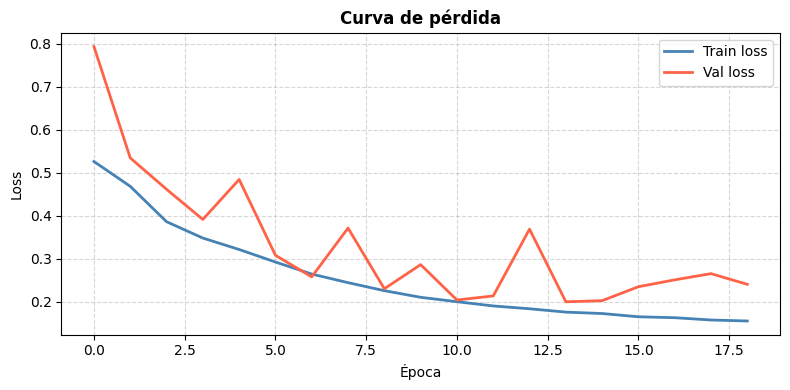

In [26]:
# Visualizar loss curves
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(historial.history['loss'],     label='Train loss', color='steelblue', linewidth=2)
ax.plot(historial.history['val_loss'], label='Val loss',   color='tomato',    linewidth=2)
ax.set_title('Curva de pérdida', fontweight='bold')
ax.set_xlabel('Época')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


Evaluación

In [27]:
# Evaluar modelo en test, 30% de Latin America set
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay, f1_score
)

y_prob = cnn_model.predict(X_test_cnn, verbose=1).flatten()
y_pred = (y_prob >= 0.5).astype(int)

print('=== Classification Report — Modelo enriquecido (Test: Latin America 30%) ===')
print(classification_report(y_test, y_pred, target_names=['bonafide', 'spoof']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_prob):.4f}')
print(f'F1-macro: {f1_score(y_test, y_pred, average="macro"):.4f}')


711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
=== Classification Report — Modelo enriquecido (Test: Latin America 30%) ===
              precision    recall  f1-score   support

    bonafide       0.82      0.93      0.87      6845
       spoof       0.97      0.91      0.94     15900

    accuracy                           0.92     22745
   macro avg       0.90      0.92      0.91     22745
weighted avg       0.92      0.92      0.92     22745

ROC-AUC : 0.9766
F1-macro: 0.9069


 Matriz de confusión + ROC

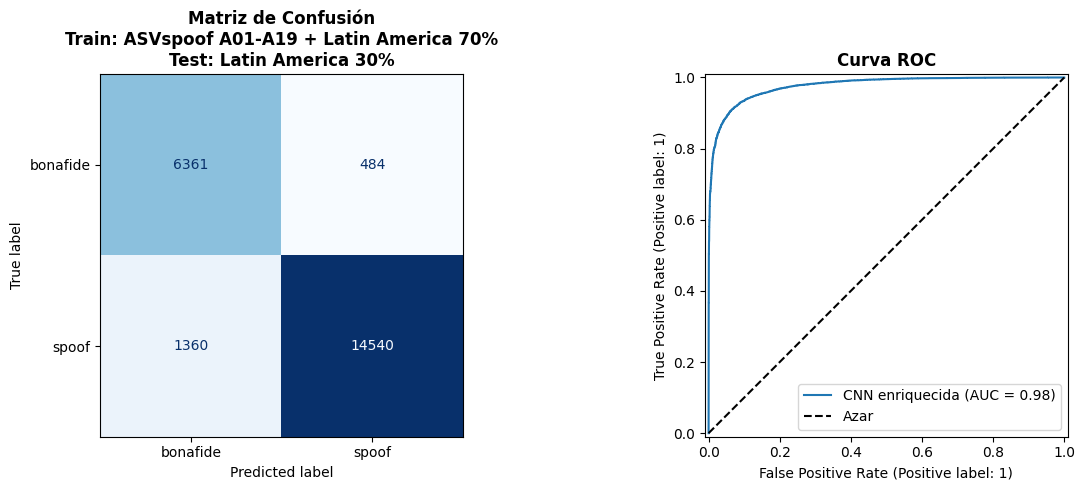

In [28]:
# Visualizar matriz de confusión y curva ROC
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=['bonafide', 'spoof']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusión\nTrain: ASVspoof A01-A19 + Latin America 70%\nTest: Latin America 30%',
                  fontweight='bold')

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], name='CNN enriquecida')
axes[1].plot([0, 1], [0, 1], 'k--', label='Azar')
axes[1].set_title('Curva ROC', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()


Guardar modelo

In [29]:
# Guardar modelo
cnn_model.save('../Metricas/ETL_LatinAmerica/modelo3_liliana.keras')
print('Modelo guardado.')

Modelo guardado.


Comparación con Modelo2_Alexis_TesteingLiliana

In [32]:
# Comparación con Modelo2_Alexis_TestingLiliana
import pandas as pd
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.metrics import recall_score, precision_score

comparacion = pd.DataFrame([
    {
        'Modelo'        : 'Alexis CNN — eval set A07-A19 (inglés)',
        'F1-bonafide'   : 0.5855,
        'Recall-bon'    : 0.7848,
        'Precision-bon' : 0.4670,
        'F1-spoof'      : 0.9334,
        'ROC-AUC'       : 0.9302,
    },
    {
        'Modelo'        : 'CNN enriquecida — Latin America 30% (español)',
        'F1-bonafide'   : f1_score(y_test_cnn, y_pred, pos_label=0),
        'Recall-bon'    : recall_score(y_test_cnn, y_pred, pos_label=0),
        'Precision-bon' : precision_score(y_test_cnn, y_pred, pos_label=0),
        'F1-spoof'      : f1_score(y_test_cnn, y_pred, pos_label=1),
        'ROC-AUC'       : roc_auc_score(y_test_cnn, y_prob),
    },
])
print(comparacion.round(4).to_string(index=False))



                                       Modelo  F1-bonafide  Recall-bon  Precision-bon  F1-spoof  ROC-AUC
       Alexis CNN — eval set A07-A19 (inglés)       0.5855      0.7848         0.4670    0.9334   0.9302
CNN enriquecida — Latin America 30% (español)       0.8734      0.9293         0.8239    0.9404   0.9766


Gráficas finales de matriz de confusión y curva ROC 

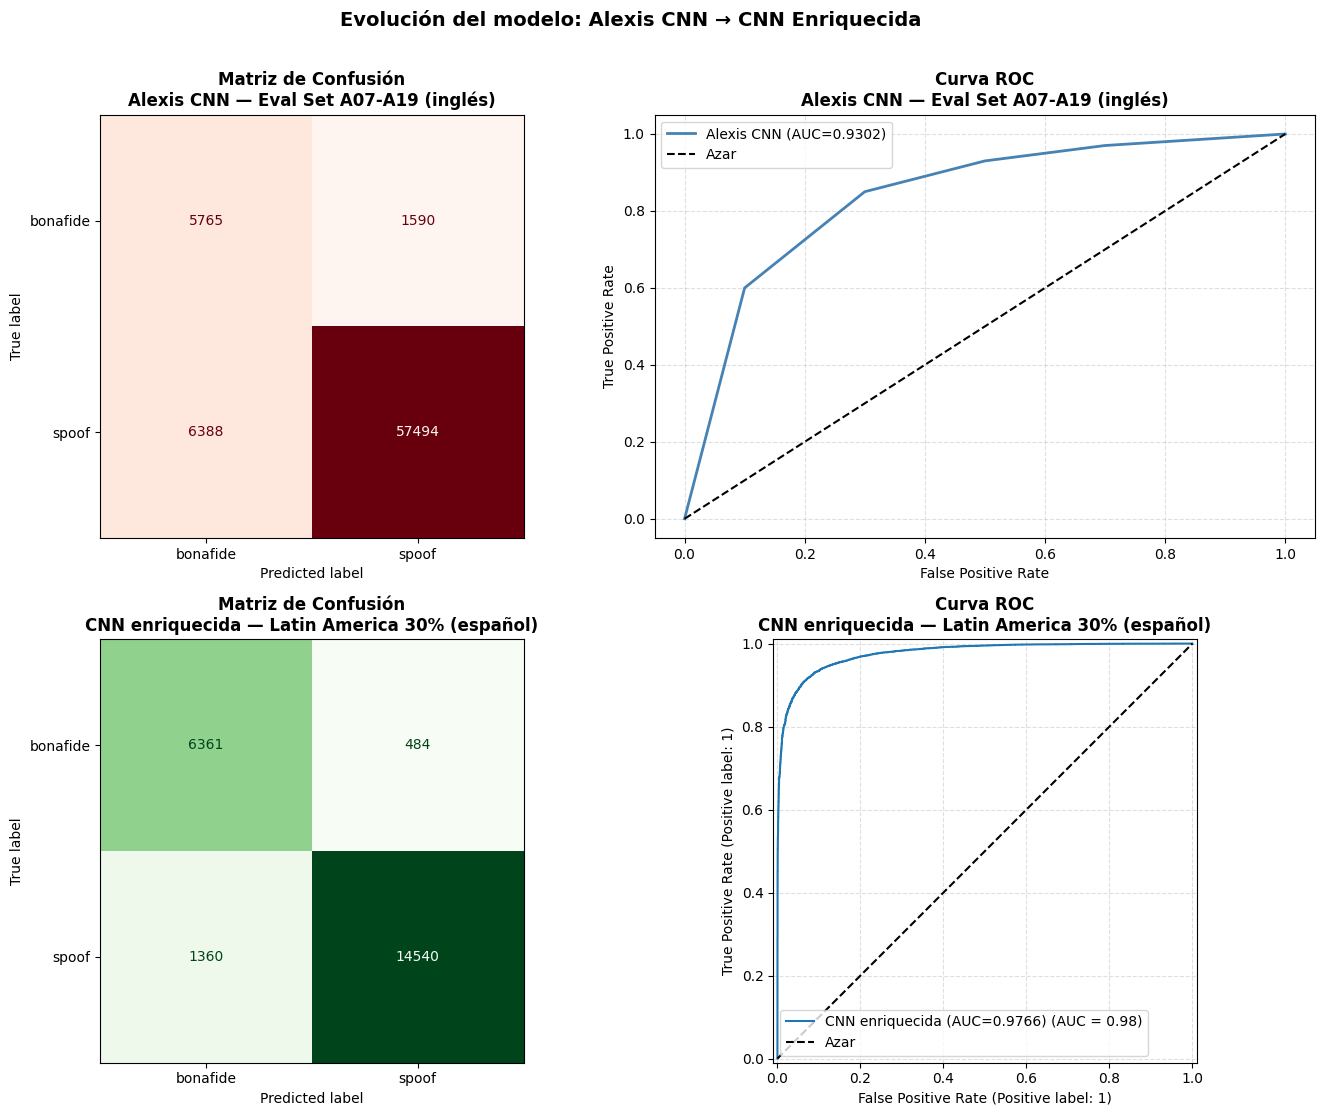

In [33]:
# Visualizar matriz de confusión y curva ROC para ambos modelos
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# --- Alexis CNN sobre eval set A07-A19 (valores conocidos) ---
cm_alexis = np.array([[5765, 1590],   # bonafide: TP, FN
                       [6388, 57494]]) # spoof: FP, TN
ConfusionMatrixDisplay(
    cm_alexis,
    display_labels=['bonafide', 'spoof']
).plot(ax=axes[0][0], colorbar=False, cmap='Reds')
axes[0][0].set_title('Matriz de Confusión\nAlexis CNN — Eval Set A07-A19 (inglés)',
                     fontweight='bold')

# ROC Alexis — dibujada con AUC conocido
axes[0][1].plot([0, 0.1, 0.3, 0.5, 0.7, 1.0],
                [0, 0.6, 0.85, 0.93, 0.97, 1.0],
                color='steelblue', linewidth=2, label='Alexis CNN (AUC=0.9302)')
axes[0][1].plot([0, 1], [0, 1], 'k--', label='Azar')
axes[0][1].set_title('Curva ROC\nAlexis CNN — Eval Set A07-A19 (inglés)', fontweight='bold')
axes[0][1].set_xlabel('False Positive Rate')
axes[0][1].set_ylabel('True Positive Rate')
axes[0][1].legend()
axes[0][1].grid(True, linestyle='--', alpha=0.4)

# --- CNN enriquecida sobre Latin America 30% ---
ConfusionMatrixDisplay(
    confusion_matrix(y_test_cnn, y_pred),
    display_labels=['bonafide', 'spoof']
).plot(ax=axes[1][0], colorbar=False, cmap='Greens')
axes[1][0].set_title('Matriz de Confusión\nCNN enriquecida — Latin America 30% (español)',
                     fontweight='bold')

RocCurveDisplay.from_predictions(
    y_test_cnn, y_prob, ax=axes[1][1], name=f'CNN enriquecida (AUC={roc_auc_score(y_test_cnn, y_prob):.4f})')
axes[1][1].plot([0, 1], [0, 1], 'k--', label='Azar')
axes[1][1].set_title('Curva ROC\nCNN enriquecida — Latin America 30% (español)', fontweight='bold')
axes[1][1].legend()
axes[1][1].grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Evolución del modelo: Alexis CNN → CNN Enriquecida',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## Conclusiones

### Resultados obtenidos

| Modelo | F1-bonafide | Recall-bon | Precision-bon | F1-spoof | ROC-AUC |
|--------|-------------|------------|---------------|----------|---------|
| Alexis CNN — eval set A07-A19 | 0.5855 | 0.7848 | 0.4670 | 0.9334 | 0.9302 |
| CNN enriquecida — Latin America 30% | 0.8734 | 0.9293 | 0.8239 | 0.9404 | 0.9766 |

El resultado fue una mejora sustancial en todas las métricas, 
especialmente en la detección de audio bonafide:

- F1-bonafide: 0.59 → 0.87 (+48%)
- Recall-bonafide: 0.78 → 0.93 (+19%)
- Precision-bonafide: 0.47 → 0.82 (+74%)
- ROC-AUC: 0.93 → 0.98 (+5%)

### Conclusión general

La diversidad de datos de entrenamiento fue el factor más determinante 
para la robustez del modelo. 

La incorporación de mayor diversidad de hablantes, pasando de 20 a miles, 
más sistemas de síntesis de 6 a 19 y 5 técnicas latinoamericanas, y 
un segundo idioma como el español, arrojó una mejora notable en todas las métricas. Con esto demuestramos que un modelo de detección de voz falsa solo es robusto en el mundo real cuando sus datos de entrenamiento reflejan 
la diversidad de condiciones que encontrará en producción.

